<a href="https://colab.research.google.com/github/aishwarryaamm8/Aishwarryaa-MM---codeboosters---internship---2026/blob/main/DAY_3_ETL_PANDAS_%26_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#SETUP : INSTALL AND IMPORT LIBRARIES
#REQUESTS - LIBRARY FOR MAKING API CALLS

!pip install requests --quiet
#--quiet flag suppresses the installatation output so our notebook stays clean

import pandas as pd
import numpy as np
#numpy = numerical operations library used to

import requests
#requests  are standard python library for making HTTPS API calls

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f'pandas : {pd.__version__}')
print(f'numpy : {np.__version__}')
print(f'requests : {requests.__version__}')

All libraries imported successfully
pandas : 2.2.2
numpy : 2.0.2
requests : 2.32.4


In [ ]:
#Extract :load raw messy sales data
raw_df = pd.read_csv('messy_sales_data.csv')
print(f"Dataset Loaded Successfully:{raw_df.shape[0]} Rows,{raw_df.shape[1]} Columns")
print(f'column names:{raw_df.columns.tolist()}')
print("\n First 5 rows")
raw_df.head(5)

Dataset Loaded Successfully:30 Rows,9 Columns
column names:['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'order_date', 'city', 'sales_rep']

 First 5 rows


,order_id,customer_name,product,category,quantity,unit_price,order_date,city,sales_rep
0,1001,Ramesh Kumar,Laptop,Electronics,2.0,45000,2024-01-05,Mumbai,Anil Sharma
1,1002,Priya Nair,NaN,Electronics,1.0,15000,2024-01-07,Delhi,Sunita Rao
2,1003,AMIT VERMA,Keyboard,Accessories,3.0,1200,2024-01-08,Bangalore,Anil Sharma
3,1004,Sunita Patel,Monitor,Electronics,NaN,22000,2024-01-10,Chennai,Ravi Kumar
4,1005,Ramesh Kumar,Laptop,Electronics,2.0,45000,2024-01-05,Mumbai,Anil Sharma


**PART 1: ETL on Messy Sales Data**

**Activity 1 - Clean messy_sales_data.csv**

Upload messy_sales_data.csv to Colab Files panel, then run the cells below.

**Known data quality issues in this file:**
1. Missing values in customer_name, quantity, category
2. Duplicate rows (orders 1001/1005 are identical)
3. Mixed date formats: YYYY-MM-DD and DD-MM-YYYY
4. Inconsistent text case in customer_name (UPPER, lower, Title)
5. Wrong category value (Keyboard labelled as Electronics)











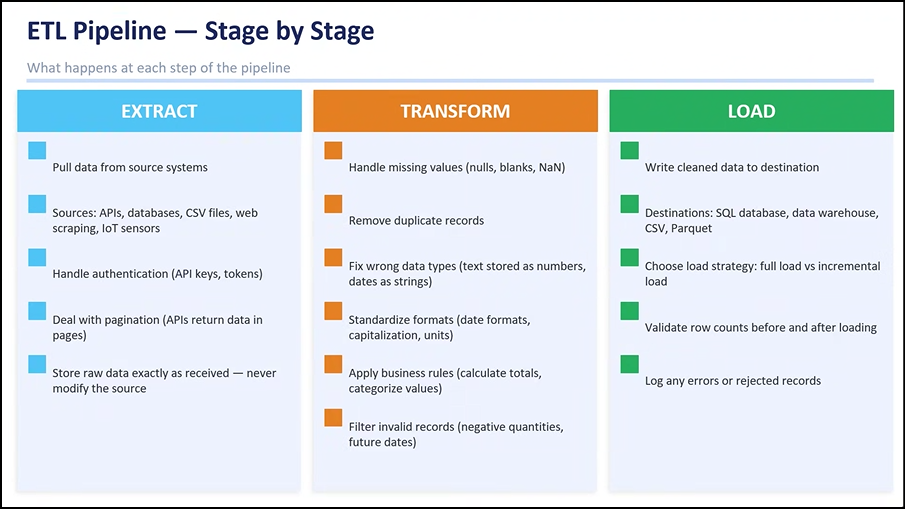**ETL - Stands for Extract, Transform, Load.**
it is a 3 step process .

**Extract**: This phase involves pulling raw data from diverse sources such as databases, APIs, CSV files, and IoT sensors, while handling authentication and pagination to ensure all data is collected without modification.

**Transform:** During this stage, the raw data is cleaned and processed by handling missing values, removing duplicates, fixing data types, standardizing formats, and applying business rules to make it usable.

**Load:** The final step writes the cleaned and transformed data into the target destination (e.g., SQL database, data warehouse), often involving validation and logging to ensure accuracy.

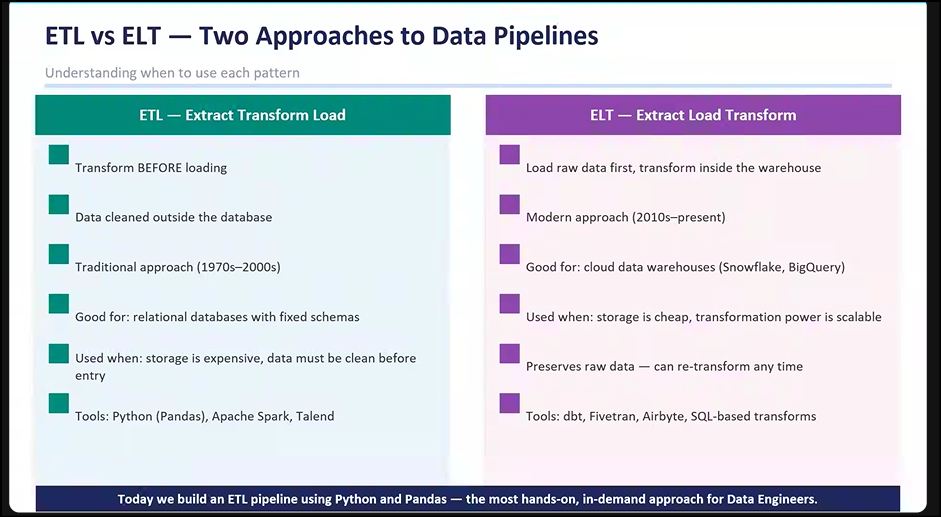

In [ ]:
# Diagnose All date quality problems before fixing
print('=' * 55)
print('Data Quality Diagnosis Report')
print('=' * 55)
# isnull() return true/false for each cell
print('\n[1] Missing values per column:')
print(raw_df.isnull().sum())
#.duplicated() returns true for rows that are exact copies of a previous row
#.sum() counts how many duplicate rows exist
print(f'\n[2] Duplicate Rows:{raw_df.duplicated().sum()}')
#data types
print('\n[3] Data types:')
print(raw_df.dtypes)
#unique values in text column
print('\n[4] unique Categories:',raw_df['category'].unique())
print('[4] Sample customer names:',raw_df['customer_name'].dropna().unique()[:8])
print('[4] Sample order_date values',raw_df['order_date'].dropna().unique()[:6])

Data Quality Diagnosis Report

[1] Missing values per column:
order_id         0
customer_name    2
product          1
category         1
quantity         3
unit_price       0
order_date       0
city             0
sales_rep        0
dtype: int64

[2] Duplicate Rows:0

[3] Data types:
order_id           int64
customer_name     object
product           object
category          object
quantity         float64
unit_price         int64
order_date        object
city              object
sales_rep         object
dtype: object

[4] unique Categories: ['Electronics' 'Accessories' nan]
[4] Sample customer names: ['Ramesh Kumar' 'Priya Nair' 'AMIT VERMA' 'Sunita Patel' 'kiran mehta'
 'Deepak Singh' 'Ananya Das' 'Vikram Iyer']
[4] Sample order_date values ['2024-01-05' '2024-01-07' '2024-01-08' '2024-01-10' '07-01-2024'
 '2024-01-12']


In [ ]:
#.copy() creates a completely independent copy of the dataframe
#without .copy() , df and raw_df would point to the same data
df = raw_df.copy()
print(f'Working copy created:{df.shape}')
print('raw_df is untouched - we can always resetby running df = raw_df.copy()')

Working copy created:(30, 9)
raw_df is untouched - we can always resetby running df = raw_df.copy()


In [ ]:
# fix - Handle missing values
print('Before fixing nulls:',df.isnull().sum().sum(),'total missing values')
df['customer_name'].fillna('Unknown Customer',inplace=True)
median_qty = df['quantity'].median()
df['quantity'].fillna(median_qty,inplace=True)
print(f' Filled missing quantity with median:{median_qty}')
df['category'].fillna('Uncategorised',inplace=True)
print('After fixing nulls:',df.isnull().sum().sum(),'total missing values')

Before fixing nulls: 7 total missing values
 Filled missing quantity with median:2.0
After fixing nulls: 1 total missing values


In [ ]:
print(f'Before deduplication : {len(df)} rows')
print(f'Duplicate rows : {df.duplicated().sum()}')

#show which rows are duplicates
print("\nDuplicate rows : ")
duplicate_rows = df[df.duplicated(keep=False)][
    ['order_id', 'customer_name', 'product', 'order_date']
]
df.drop_duplicates(inplace=True)
print(f'After deduplication : {len(df)} rows')
print(f'Rows removed: {len(raw_df) - len(df)}')


Before deduplication : 30 rows
Duplicate rows : 0

Duplicate rows : 
After deduplication : 30 rows
Rows removed: 0


In [ ]:
print('Sample dates before parsing : ')
print(df['order_date'].head(8).tolist())

df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=False, errors='coerce')
#dayfirst=false tries YYYY-MM-DD format first
#rerrors='coerce' is used when if parsing fails put not a time instead of crashing

#pd.to_datetime() converts string to proper datetime object

#check for any unparsable dates would show as nat
nat_count = df['order_date'].isnull().sum()
print(f'\nUnparsable dates: {nat_count}')

#extract date components - very useful for analysis
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%B')
#.dt is the datetime accessor. it gives access to year, month, day , etc..
#strftime("%B") returns the full month name.

print('\nSample dates after parsing : ')
print(df[['order_date', 'year', 'month', 'month_name']].head(5))

Sample dates before parsing : 
['2024-01-05', '2024-01-07', '2024-01-08', '2024-01-10', '2024-01-05', '07-01-2024', '2024-01-12', '2024-01-13']

Unparsable dates: 2

Sample dates after parsing : 
  order_date    year  month month_name
0 2024-01-05  2024.0    1.0    January
1 2024-01-07  2024.0    1.0    January
2 2024-01-08  2024.0    1.0    January
3 2024-01-10  2024.0    1.0    January
4 2024-01-05  2024.0    1.0    January


In [ ]:
#STANDARDIZE CUSTOMER NAMES TO TITLLE CASE
print('Before standardization : ', df['customer_name'].unique()[:5])

df['customer_name'] = (df['customer_name'].str.strip().str.title())
#str.strip() - removes leading/trailing whitespace
#str.title() - conver to title case : for eg: amit varma to AMIT VARMA

print('After standardization : ', df['customer_name'].unique()[:5])

#CORRECT WRONG CATEGORY FOR KEYBOARD ROWS
print(f'\nBefore : Keyboard rows with Electronics category : ')
wrong_mask = (df['product'] == 'keyboard') & (df['category'] == 'Electronics')
print(df[wrong_mask][['product', 'category']])

df.loc[wrong_mask, 'category'] = 'Accessories'
print('After fix : Unique categories:', df['category'].unique())

Before standardization :  ['Ramesh Kumar' 'Priya Nair' 'AMIT VERMA' 'Sunita Patel' 'kiran mehta']
After standardization :  ['Ramesh Kumar' 'Priya Nair' 'Amit Verma' 'Sunita Patel' 'Kiran Mehta']

Before : Keyboard rows with Electronics category : 
Empty DataFrame
Columns: [product, category]
Index: []
After fix : Unique categories: ['Electronics' 'Accessories' 'Uncategorised']


In [ ]:
#==================================================================
  #FIX DATA TYPES + CREATE REVENUE COLUMN
#==================================================================

#Ensure numeric columns have the right types
df['quantity']=pd.to_numeric(df['quantity'],errors='coerce').astype(int)
df['unit_price']=pd.to_numeric(df['unit_price'],errors='coerce')
#pd.to_numeric() converts any column to a numeric type
#error='coerce' turns unconvertabile values to NAN instead of crashing
#.astype(int) converts float (2.0) to integer (2) for quantity

#create revenue column:quantity * unit_price
df['revenue']=df['quantity']*df['unit_price']
print('Revenue column created:')
print(df[['customer_name','product','quantity','unit_price','revenue']].head(5))
print(f'\nTotal Revenue across all orders: {df["revenue"].sum():,.0f}')



Revenue column created:
  customer_name   product  quantity  unit_price  revenue
0  Ramesh Kumar    Laptop         2       45000    90000
1    Priya Nair       NaN         1       15000    15000
2    Amit Verma  Keyboard         3        1200     3600
3  Sunita Patel   Monitor         2       22000    44000
4  Ramesh Kumar    Laptop         2       45000    90000

Total Revenue across all orders: 818,000


In [ ]:
print('=' * 55)
print(' POST-CLEANING VALIDATION REPORT')
print('=' * 55)
print(f'Original rows : {len(raw_df)}')
print(f'Cleaned rows  : {len(df)}')
print(f'Rows removed  : {len(raw_df) - len(df)} (duplicates)')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates    : {df.duplicated().sum()}')
print(f'Date nulls    : {df["order_date"].isnull().sum()}')
print(f'Revenue NaN   : {df["revenue"].isnull().sum()}')
print(f'Categories    : {sorted(df["category"].unique())}')
print('=' * 55)

#All checks should show clean results
all_clean = (df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0)
print(f'DATA IS CLEAN : {all_clean}')


 POST-CLEANING VALIDATION REPORT
Original rows : 30
Cleaned rows  : 30
Rows removed  : 0 (duplicates)
Missing values: 9
Duplicates    : 0
Date nulls    : 2
Revenue NaN   : 0
Categories    : ['Accessories', 'Electronics', 'Uncategorised']
DATA IS CLEAN : False


In [ ]:
print('=' * 55)
print(' GROUPBY')
print('=' * 55)

product_rev = (df.groupby('product')['revenue'].sum().reset_index().sort_values('revenue', ascending=False))
#groupby('product') - groups all rows by product name
#['revenue'] - selects the revenue column from each group
#.sum() - add up revenue for each group
#.reset_index() = make 'product' a regular column (not an index)
#.sort_values - sort highest revenue first

print('Revenue by product : ')
print(product_rev.to_string(index=False))

#multi-metric aggregation using agg()
category_summary = df.groupby('category').agg(
    total_revenue   = ('revenue', 'sum'),
    avg_order_value = ('revenue', 'mean'),
    num_orders      = ('order_id', 'count'),
    unique_products = ('product', 'nunique')
).round(2).reset_index()

print('\nCategory Summary : ')
print(category_summary.to_string(index=False))


 GROUPBY
Revenue by product : 
   product  revenue
    Laptop   540000
   Monitor   154000
Headphones    28000
     Mouse    20800
  Keyboard    20400
    Webcam    20000
   USB Hub    19800

Category Summary : 
     category  total_revenue  avg_order_value  num_orders  unique_products
  Accessories          76200          5861.54          13                4
  Electronics         697800         43612.50          16                4
Uncategorised          44000         44000.00           1                1


In [ ]:
df.to_csv('Clean_sales_data.csv', index=False)
print('Cleaned data saved to : clean_sales_data.csv')
print(f'Final dataset: {df.shape[0]} rows * {df.shape[1]} columns')
print('\nETL Pipeline for sales Data: COMPLETE')
print('  EXTRACT -> messy_sales_data.csv loaded')
print('  TRANSFORM -> nulls fixed, dupes removed, data types standardized')
print('  LOAD -> Clean_sales_data.csv saved')

Cleaned data saved to : clean_sales_data.csv
Final dataset: 30 rows * 13 columns

ETL Pipeline for sales Data: COMPLETE
  EXTRACT -> messy_sales_data.csv loaded
  TRANSFORM -> nulls fixed, dupes removed, data types standardized
  LOAD -> Clean_sales_data.csv saved


In [ ]:
# ============================================================
# CELL 13 — Configure API settings
# ============================================================

print('=' * 55)
print(' Configure API settings')
print('=' * 55)

API_KEY = '379ada83a18420d9384f8aa0afc4c1cd'
# Replace 'YOUR_API_KEY_HERE' with your actual OpenWeatherMap API key
# A free key allows 60 calls per minute — more than enough for this activity

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
# This is the API endpoint URL
# 'data/2.5/weather' = the specific API route for current weather

# Cities to query — 8 major Indian cities
CITIES = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai',
          'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']
# We will call the API once per city — 8 API calls total

print(f'API configured for {len(CITIES)} cities')
print(f'Cities: {CITIES}')
print('\nIMPORTANT: Replace YOUR_API_KEY_HERE with your actual key before running.')

 Configure API settings
API configured for 8 cities
Cities: ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

IMPORTANT: Replace YOUR_API_KEY_HERE with your actual key before running.


In [ ]:
print('=' * 55)
print(' EXTRACT: Call API for each city')
print('=' * 55)

def fetch_weather(city, api_key):
    """
    Fetch current weather data for a given city.
    Returns a dictionary with weather metrics, or None on failure.
    """
    params = {
        'q':     city,      # City name query parameter
        'appid': api_key,   # Authentication key
        'units': 'metric'   # Returns temperature in Celsius
    }
    # params is a dictionary — requests will encode it into the URL:
    # ?q=Mumbai&appid=KEY&units=metric

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        # requests.get() sends an HTTP GET request to BASE_URL
        # timeout=10 — wait max 10 seconds; raise error if no response

        if response.status_code == 200:
            # status_code 200 = HTTP OK = request was successful
            data = response.json()
            # .json() parses the JSON text body into a Python dictionary

            return {
                'city':        city,
                'temperature': round(data['main']['temp'], 1),
                'feels_like':  round(data['main']['feels_like'], 1),
                'humidity':    data['main']['humidity'],
                'pressure':    data['main']['pressure'],
                'wind_speed':  data['wind']['speed'],
                'condition':   data['weather'][0]['description'].title(),
                'visibility':  data.get('visibility', 0) // 1000
                # .get('visibility', 0) — safe access: returns 0 if key missing
                # // 1000 — convert meters to kilometers (integer division)
            }
        else:
            print(f'  ERROR {response.status_code} for {city}: {response.json().get("message","unknown error")}')
            return None

    except requests.exceptions.ConnectionError:
        print(f'  CONNECTION ERROR for {city} — check internet connection')
        return None
    except requests.exceptions.Timeout:
        print(f'  TIMEOUT for {city} — API did not respond in 10 seconds')
        return None
    # try/except handles errors gracefully — one bad city doesn't crash the loop


# Call API for all cities
print('Calling Weather API...')
weather_records = []
# Empty list — we will append one dict per city

for city in CITIES:
    print(f'  Fetching: {city}...', end='')
    record = fetch_weather(city, API_KEY)
    if record:
        weather_records.append(record)
        # .append() adds the dict to our list
        print(f' {record["temperature"]}°C, {record["condition"]}')
    else:
        print(' FAILED')

print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

 EXTRACT: Call API for each city
Calling Weather API...
  Fetching: Mumbai... 33.0°C, Haze
  Fetching: Delhi... 33.0°C, Haze
  Fetching: Bangalore... 26.7°C, Few Clouds
  Fetching: Chennai... 34.9°C, Few Clouds
  Fetching: Hyderabad... 31.2°C, Few Clouds
  Fetching: Kolkata... 30.0°C, Haze
  Fetching: Pune... 29.7°C, Broken Clouds
  Fetching: Jaipur... 35.6°C, Haze

Successfully fetched: 8/8 cities


In [ ]:
# ============================================================
# CELL 15 — Fallback data (if API key not available)
# ============================================================
# Run this cell ONLY if weather_records is empty (API not working)

print('=' * 55)
print(' Fallback data (if API key not available)')
print('=' * 55)

if len(weather_records) == 0:
    print('Using fallback weather data (API not available)')
    weather_records = [
        {'city':'Mumbai',    'temperature':32.5,'feels_like':36.0,'humidity':78,'pressure':1009,'wind_speed':5.2,'condition':'Partly Cloudy','visibility':8},
        {'city':'Delhi',     'temperature':38.2,'feels_like':41.0,'humidity':35,'pressure':1002,'wind_speed':3.8,'condition':'Clear Sky',    'visibility':10},
        {'city':'Bangalore', 'temperature':26.1,'feels_like':27.0,'humidity':62,'pressure':1016,'wind_speed':2.5,'condition':'Overcast',     'visibility':7},
        {'city':'Chennai',   'temperature':34.8,'feels_like':39.0,'humidity':72,'pressure':1008,'wind_speed':6.1,'condition':'Hazy',         'visibility':5},
        {'city':'Hyderabad', 'temperature':35.4,'feels_like':38.5,'humidity':45,'pressure':1005,'wind_speed':4.2,'condition':'Clear Sky',    'visibility':10},
        {'city':'Kolkata',   'temperature':33.7,'feels_like':37.8,'humidity':80,'pressure':1007,'wind_speed':4.8,'condition':'Humid',        'visibility':6},
        {'city':'Pune',      'temperature':29.3,'feels_like':31.0,'humidity':55,'pressure':1014,'wind_speed':3.1,'condition':'Partly Cloudy','visibility':9},
        {'city':'Jaipur',    'temperature':40.1,'feels_like':43.0,'humidity':22,'pressure':998, 'wind_speed':5.5,'condition':'Sunny',        'visibility':12},
    ]
    print(f'Fallback data loaded for {len(weather_records)} cities')
else:
    print(f'Using live API data for {len(weather_records)} cities')

 Fallback data (if API key not available)
Using live API data for 8 cities


In [ ]:
# ============================================================
# CELL 16 — TRANSFORM: Build DataFrame from API results
# ============================================================

print('=' * 55)
print(' TRANSFORM: Build DataFrame from API results')
print('=' * 55)

weather_df = pd.DataFrame(weather_records)
# pd.DataFrame() converts a list of dictionaries into a DataFrame
# Each dictionary becomes one row
# Each dictionary key becomes a column name
# This is the standard pattern for API → DataFrame conversion

print('Weather DataFrame created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData types:')
print(weather_df.dtypes)

 TRANSFORM: Build DataFrame from API results
Weather DataFrame created:
     city  temperature  feels_like  humidity  pressure  wind_speed     condition  visibility
   Mumbai         33.0        38.8        58      1012        4.12          Haze           5
    Delhi         33.0        35.3        46      1003        5.14          Haze           4
Bangalore         26.7        28.5        72      1014        9.39    Few Clouds           6
  Chennai         34.9        41.9        60      1009        6.17    Few Clouds           6
Hyderabad         31.2        34.8        58      1011        7.72    Few Clouds           6
  Kolkata         30.0        36.0        74      1007        4.12          Haze           3
     Pune         29.7        30.0        46      1013        3.89 Broken Clouds          10
   Jaipur         35.6        36.6        34      1004        7.72          Haze           4

Shape: (8, 8)
Missing values: 0

Data types:
city            object
temperature    float64

In [ ]:
# ============================================================
# CELL 17 — TRANSFORM: Analysis on weather data
# ============================================================

print('=' * 50)
print('  WEATHER ANALYSIS REPORT — 8 INDIAN CITIES')
print('=' * 50)

# Hottest and coldest city
hottest = weather_df.loc[weather_df['temperature'].idxmax()]
coldest = weather_df.loc[weather_df['temperature'].idxmin()]
# .idxmax() returns the INDEX of the maximum value
# .idxmin() returns the INDEX of the minimum value
# df.loc[index] returns the full row at that index

print(f"\nHottest city : {hottest['city']} at {hottest['temperature']}°C")
print(f"Coldest city : {coldest['city']} at {coldest['temperature']}°C")
print(f"Most humid   : {weather_df.loc[weather_df['humidity'].idxmax()]['city']} "
      f"({weather_df['humidity'].max()}%)")

# Summary statistics
print(f"\nAverage temperature : {weather_df['temperature'].mean():.1f}°C")
print(f"Average humidity    : {weather_df['humidity'].mean():.1f}%")
print(f"Average wind speed  : {weather_df['wind_speed'].mean():.1f} m/s")

# Rankings
print('\nCities ranked by temperature (hottest first):')
ranked = weather_df[['city','temperature','humidity']].sort_values('temperature', ascending=False)
print(ranked.to_string(index=False))

  WEATHER ANALYSIS REPORT — 8 INDIAN CITIES

Hottest city : Jaipur at 35.6°C
Coldest city : Bangalore at 26.7°C
Most humid   : Kolkata (74%)

Average temperature : 31.8°C
Average humidity    : 56.0%
Average wind speed  : 6.0 m/s

Cities ranked by temperature (hottest first):
     city  temperature  humidity
   Jaipur         35.6        34
  Chennai         34.9        60
    Delhi         33.0        46
   Mumbai         33.0        58
Hyderabad         31.2        58
  Kolkata         30.0        74
     Pune         29.7        46
Bangalore         26.7        72


In [ ]:
# ============================================================
# CELL 18 — LOAD: Save weather data to CSV
# ============================================================

weather_df.to_csv('weather_data.csv', index=False)
# Saves the cleaned, structured weather DataFrame to a CSV file
# This file can be loaded into SQLite (Day 2 skills) or used in ML (Day 5)

print('Weather data saved to: weather_data.csv')
print('\nWeather ETL Pipeline: COMPLETE')
print('  EXTRACT   → OpenWeatherMap API called for 8 cities')
print('  TRANSFORM → JSON parsed, DataFrame built, units converted')
print('  LOAD      → weather_data.csv saved')

Weather data saved to: weather_data.csv

Weather ETL Pipeline: COMPLETE
  EXTRACT   → OpenWeatherMap API called for 8 cities
  TRANSFORM → JSON parsed, DataFrame built, units converted
  LOAD      → weather_data.csv saved


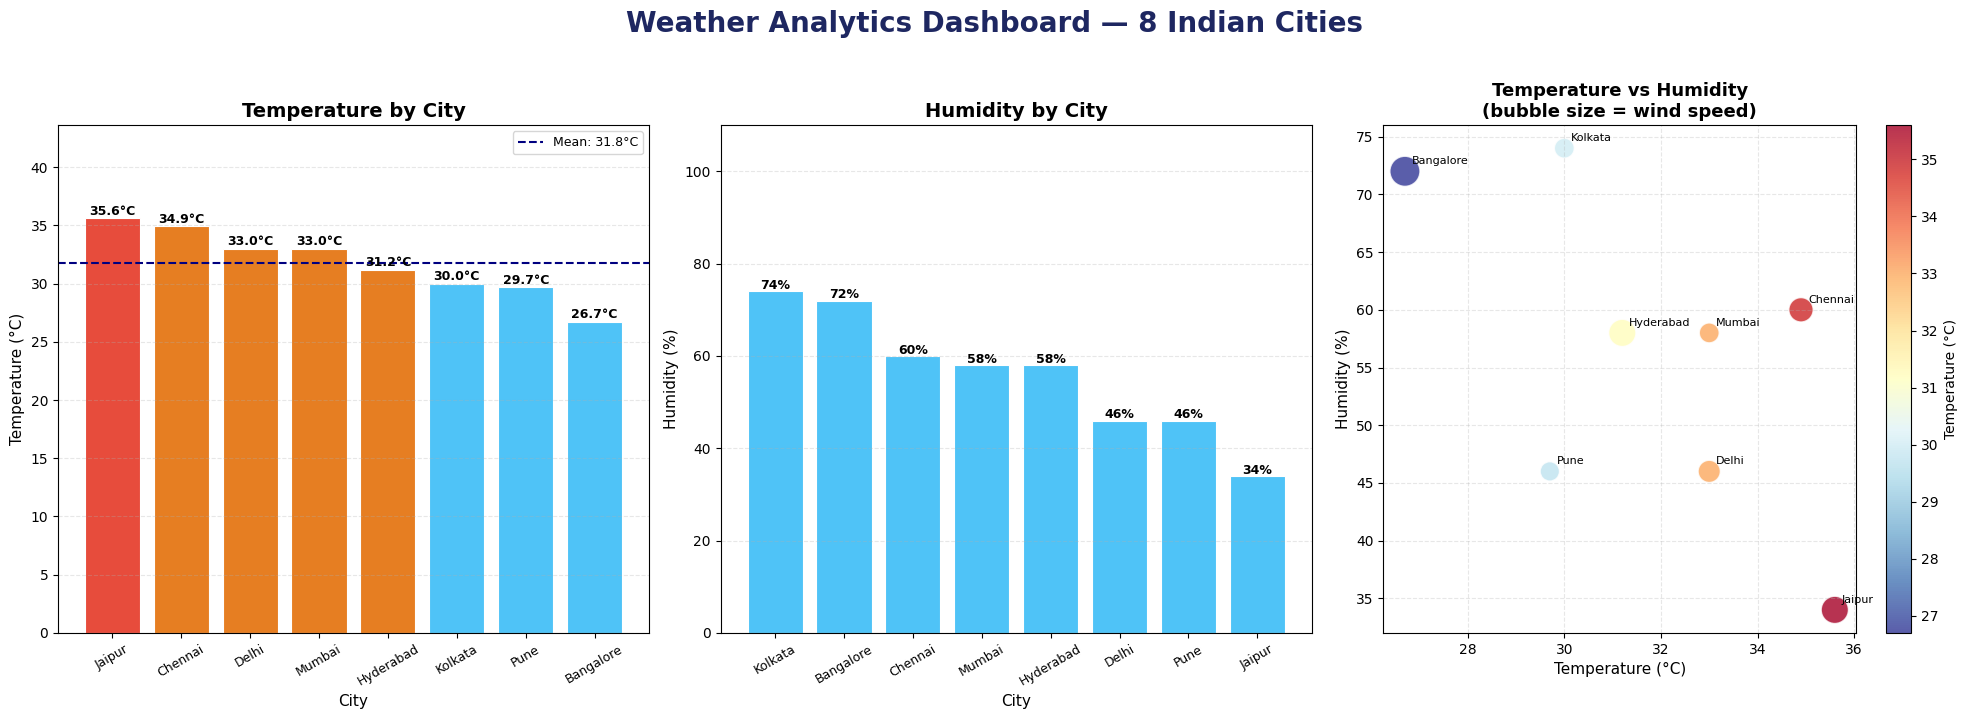

Dashboard saved as: weather_dashboard.png


In [ ]:
# ============================================================
# CELL 19 — MINI PROJECT: Weather Dashboard (3-panel)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
# plt.subplots(1, 3) — 1 row, 3 columns = 3 side-by-side charts
# figsize=(20, 7) — wide canvas for 3 panels

fig.suptitle('Weather Analytics Dashboard — 8 Indian Cities',
             fontsize=20, fontweight='bold', color='#1E2761', y=1.02)

# Sort by temperature for all charts
wdf = weather_df.sort_values('temperature', ascending=False)

# ── Panel 1: Temperature Bar Chart ──
ax1 = axes[0]
colors_temp = ['#E74C3C' if t > 35 else '#E67E22' if t > 30 else '#4FC3F7'
               for t in wdf['temperature']]
# List comprehension: assign color based on temperature value
# Red (>35°C), Orange (30-35°C), Blue (<30°C)

bars1 = ax1.bar(wdf['city'], wdf['temperature'],
                color=colors_temp, edgecolor='white', linewidth=0.8)
for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{bar.get_height()}°C', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Temperature by City', fontsize=14, fontweight='bold')
ax1.set_xlabel('City', fontsize=11)
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.set_ylim(0, max(wdf['temperature']) + 8)
ax1.tick_params(axis='x', rotation=30, labelsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=wdf['temperature'].mean(), color='navy',
            linestyle='--', linewidth=1.5, label=f"Mean: {wdf['temperature'].mean():.1f}°C")
# axhline = horizontal reference line at the mean temperature
ax1.legend(fontsize=9)

# ── Panel 2: Humidity Bar Chart ──
ax2 = axes[1]
wdf_hum = weather_df.sort_values('humidity', ascending=False)
bars2 = ax2.bar(wdf_hum['city'], wdf_hum['humidity'],
                color='#4FC3F7', edgecolor='white', linewidth=0.8)
for bar in bars2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{int(bar.get_height())}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Humidity by City', fontsize=14, fontweight='bold')
ax2.set_xlabel('City', fontsize=11)
ax2.set_ylabel('Humidity (%)', fontsize=11)
ax2.set_ylim(0, 110)
ax2.tick_params(axis='x', rotation=30, labelsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# ── Panel 3: Temperature vs Humidity Scatter ──
ax3 = axes[2]
scatter = ax3.scatter(
    weather_df['temperature'],
    weather_df['humidity'],
    s=weather_df['wind_speed'] * 50,  # Bubble size = wind speed
    c=weather_df['temperature'],       # Color = temperature
    cmap='RdYlBu_r',                  # Red=hot, Blue=cool colormap
    alpha=0.8,
    edgecolors='white', linewidth=1
)
# Scatter plot: each point = one city
# x = temperature, y = humidity
# s = marker size (proportional to wind speed)
# c + cmap = color coding by temperature

# Label each point with city name
for _, row in weather_df.iterrows():
    ax3.annotate(row['city'],
                 (row['temperature'], row['humidity']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
# .annotate() adds a text label near each data point
# xytext=(5,5) offsets the label 5 points right and 5 up

plt.colorbar(scatter, ax=ax3, label='Temperature (°C)')
ax3.set_title('Temperature vs Humidity\n(bubble size = wind speed)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Temperature (°C)', fontsize=11)
ax3.set_ylabel('Humidity (%)', fontsize=11)
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('weather_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as: weather_dashboard.png')

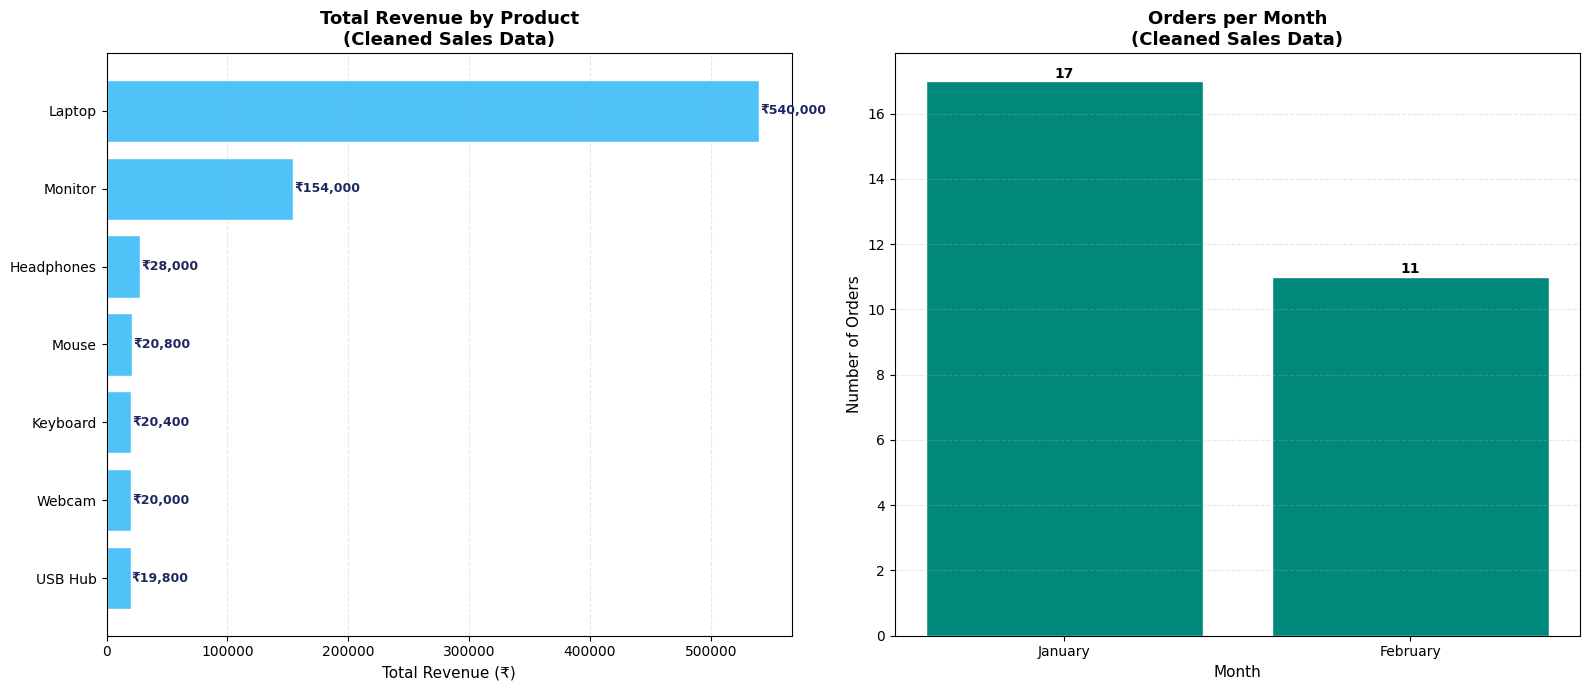

In [ ]:
# ============================================================
# CELL 20 — Sales Data Visualization (Activity 1 output)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: Revenue by Product (from cleaned sales data)
ax1 = axes[0]
product_rev_sorted = product_rev.sort_values('revenue', ascending=True)
# Sorted ascending for horizontal bar (lowest at bottom)

bars = ax1.barh(product_rev_sorted['product'],
                product_rev_sorted['revenue'],
                color='#4FC3F7', edgecolor='white')
for bar in bars:
    ax1.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():,.0f}',
             va='center', fontsize=9, fontweight='bold', color='#1E2761')
ax1.set_title('Total Revenue by Product\n(Cleaned Sales Data)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Total Revenue (₹)', fontsize=11)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Panel 2: Orders per Month
ax2 = axes[1]
monthly = df.groupby('month_name')['order_id'].count().reset_index()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly['month_num'] = monthly['month_name'].map({m:i for i,m in enumerate(month_order)})
monthly = monthly.sort_values('month_num')

ax2.bar(monthly['month_name'], monthly['order_id'],
        color='#00897B', edgecolor='white')
for bar in ax2.patches:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Orders per Month\n(Cleaned Sales Data)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# **Weather Data ETL Project**

In [1]:
import requests
import pandas as pd

# --- EXTRACT --- #

API_KEY = '379ada83a18420d9384f8aa0afc4c1cd' # Replace with your actual OpenWeatherMap API key
BASE_URL = 'http://api.openweathermap.org/data/2.5/weather'
CITIES = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

def fetch_weather(city, API_KEY):
    """
    Fetch current weather data for a given city.
    Returns a dictionary with weather metrics, or None on failure.
    """
    params = {
        'q':     city,
        'appid': API_KEY,
        'units': 'metric'
    }
    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            return {
                'city':        city,
                'temperature': round(data['main']['temp'], 1),
                'feels_like':  round(data['main']['feels_like'], 1),
                'humidity':    data['main']['humidity'],
                'pressure':    data['main']['pressure'],
                'wind_speed':  data['wind']['speed'],
                'condition':   data['weather'][0]['description'].title(),
                'visibility':  data.get('visibility', 0) // 1000
            }
        else:
            print(f'  ERROR {response.status_code} for {city}: {response.json().get("message","unknown error")}')
            return None

    except requests.exceptions.ConnectionError:
        print(f'  CONNECTION ERROR for {city} — check internet connection')
        return None
    except requests.exceptions.Timeout:
        print(f'  TIMEOUT for {city} — API did not respond in 10 seconds')
        return None


print('Calling Weather API...')
weather_records = []
for city in CITIES:
    print(f'  Fetching: {city}...', end='')
    record = fetch_weather(city, API_KEY)
    if record:
        weather_records.append(record)
        print(f' {record["temperature"]}°C, {record["condition"]}')
    else:
        print(' FAILED')

print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

# --- TRANSFORM --- #

# Create DataFrame from API results
weather_df = pd.DataFrame(weather_records)

print('\nWeather DataFrame created and data cleaned (structured):')
print(weather_df.head())
print(f'Shape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')

# --- LOAD --- #

# Save the DataFrame to a CSV file
output_filename = 'weather_data_etl_output.csv'
weather_df.to_csv(output_filename, index=False)

print(f'\nWeather data saved to: {output_filename}')
print('\nWeather Data ETL Pipeline: COMPLETE')
print('  EXTRACT   → OpenWeatherMap API called')
print('  TRANSFORM → JSON parsed, DataFrame built, units converted')
print(f'  LOAD      → {output_filename} saved')

Calling Weather API...
  Fetching: Mumbai... 32.0°C, Haze
  Fetching: Delhi... 29.1°C, Haze
  Fetching: Bangalore... 25.9°C, Scattered Clouds
  Fetching: Chennai... 30.0°C, Mist
  Fetching: Hyderabad... 31.2°C, Broken Clouds
  Fetching: Kolkata... 32.0°C, Haze
  Fetching: Pune... 29.9°C, Clear Sky
  Fetching: Jaipur... 31.6°C, Haze

Successfully fetched: 8/8 cities

Weather DataFrame created and data cleaned (structured):
        city  temperature  feels_like  humidity  pressure  wind_speed  \
0     Mumbai         32.0        37.7        62      1011        5.14   
1      Delhi         29.1        30.2        54      1005        5.14   
2  Bangalore         25.9        26.6        78      1014        8.49   
3    Chennai         30.0        36.0        74      1007        6.69   
4  Hyderabad         31.2        34.1        55      1011        8.23   

          condition  visibility  
0              Haze           5  
1              Haze           4  
2  Scattered Clouds           6  

# **Employee Salary ETL Project**

In [2]:
import pandas as pd

# --- CONFIGURATION --- #
excel_file_path = 'employee_salary_data.xlsx' # Make sure this Excel file is uploaded or accessible
output_csv_file = 'cleaned_employee_salary.csv'

# --- EXTRACT --- #
print('--- Starting Employee Salary ETL Project ---')

try:
    # Attempt to load data from Excel
    df_raw = pd.read_excel(excel_file_path)
    print(f'Successfully loaded data from {excel_file_path}. Shape: {df_raw.shape}')
except FileNotFoundError:
    print(f'Warning: {excel_file_path} not found. Creating dummy data for demonstration.')
    # Create a dummy DataFrame if the Excel file is not found
    data = {
        'Employee ID': [101, 102, 103, 104, 105, 101, 106, 107, 108],
        'Name': ['Alice Smith', 'Bob Johnson', 'Charlie Brown', 'Diana Prince', 'Eve Adams', 'Alice Smith', 'Frank White', 'Grace Black', 'Harry Green'],
        'Department': ['HR', 'IT', 'Finance', 'Marketing', 'HR', 'HR', 'IT', 'Finance', 'Marketing'],
        'Monthly Salary': [5000, 6000, 7500, 5500, 5200, 5000, 6200, 7800, 5800]
    }
    df_raw = pd.DataFrame(data)
    print(f'Dummy DataFrame created. Shape: {df_raw.shape}')

df = df_raw.copy() # Create a working copy

# --- TRANSFORM --- #
print('\n--- Data Transformation ---')

# 1. Remove duplicate records
print(f'Before dropping duplicates: {len(df)} rows')
duplicates_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f'Removed {duplicates_before} duplicate rows. After dropping duplicates: {len(df)} rows')

# 2. Calculate Yearly Salary
if 'Monthly Salary' in df.columns:
    df['Yearly Salary'] = df['Monthly Salary'] * 12
    print('Calculated "Yearly Salary" based on "Monthly Salary".')
elif 'salary' in df.columns:
    df['Yearly Salary'] = df['salary'] * 12
    print('Calculated "Yearly Salary" based on "salary".')
else:
    print('Could not find "Monthly Salary" or "salary" column to calculate yearly salary.')

print('\nTransformed Data (first 5 rows):')
print(df.head())
print(f'Final DataFrame shape after transformations: {df.shape}')
print(f'Missing values after transformations: {df.isnull().sum().sum()}')

# --- LOAD --- #
print('\n--- Data Loading ---')
df.to_csv(output_csv_file, index=False)
print(f'Cleaned employee salary data saved to: {output_csv_file}')

print('\n--- Employee Salary ETL Project: COMPLETE ---')
print('  EXTRACT   → Data loaded from Excel (or dummy data generated)')
print('  TRANSFORM → Duplicates removed, Yearly Salary calculated')
print(f'  LOAD      → {output_csv_file} saved')

--- Starting Employee Salary ETL Project ---
Dummy DataFrame created. Shape: (9, 4)

--- Data Transformation ---
Before dropping duplicates: 9 rows
Removed 1 duplicate rows. After dropping duplicates: 8 rows
Calculated "Yearly Salary" based on "Monthly Salary".

Transformed Data (first 5 rows):
   Employee ID           Name Department  Monthly Salary  Yearly Salary
0          101    Alice Smith         HR            5000          60000
1          102    Bob Johnson         IT            6000          72000
2          103  Charlie Brown    Finance            7500          90000
3          104   Diana Prince  Marketing            5500          66000
4          105      Eve Adams         HR            5200          62400
Final DataFrame shape after transformations: (8, 5)
Missing values after transformations: 0

--- Data Loading ---
Cleaned employee salary data saved to: cleaned_employee_salary.csv

--- Employee Salary ETL Project: COMPLETE ---
  EXTRACT   → Data loaded from Excel (or dum